In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [69]:
dfUSA = df[df["job_country"] == "United States"]
dfUSA = dfUSA.explode("job_skills")
dfUSA = dfUSA.dropna(subset=['job_skills'])
dfUSAgr = dfUSA.groupby(["job_skills", "job_title_short"]).size().reset_index()
dfUSAgr.columns = ['job_skills', 'job_title_short', 'skill_count']
dfUSAgr = dfUSAgr.sort_values(by ="skill_count", ascending= False)
dfUSAgr 




,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


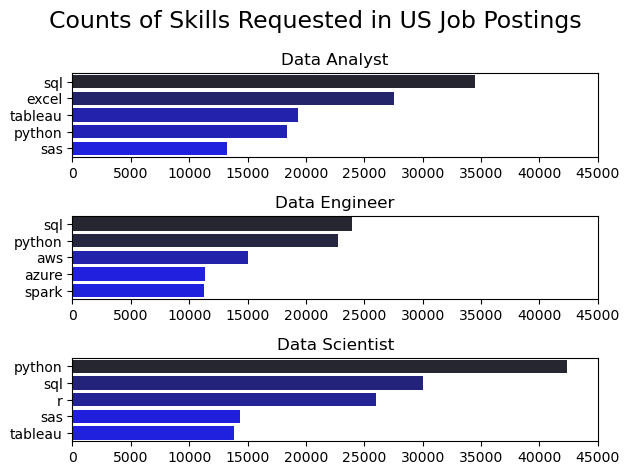

In [56]:
Jobs = df["job_title_short"].value_counts().head(3).index.to_list()
Jobs

fig, ax = plt.subplots(3,1)

for i,job_title in enumerate(Jobs):
    df_plot = dfUSAgr[dfUSAgr['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 45000) 

fig.suptitle('Counts of Skills Requested in US Job Postings', fontsize=17)
fig.tight_layout()

In [83]:



dfPostings = df[df["job_country"]=="United States"]["job_title_short"].value_counts().to_frame().reset_index()
dfPostings.columns = ["job_title_short", "job_postings_count"] 
dfMerged = dfUSAgr.merge(dfPostings, on = "job_title_short", how = "left")
dfMerged["percentage"] =  (dfMerged["skill_count"]/dfMerged["job_postings_count"]*100).round(1)

dfMerged




,job_skills,job_title_short,skill_count,job_postings_count,percentage
0,python,Data Scientist,42379,58830,72.0
1,sql,Data Analyst,34452,67816,50.8
2,sql,Data Scientist,30034,58830,51.1
3,excel,Data Analyst,27519,67816,40.6
4,r,Data Scientist,26022,58830,44.2
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.0
1866,arch,Business Analyst,1,7382,0.0
1867,asana,Machine Learning Engineer,1,921,0.1
1868,no-sql,Machine Learning Engineer,1,921,0.1


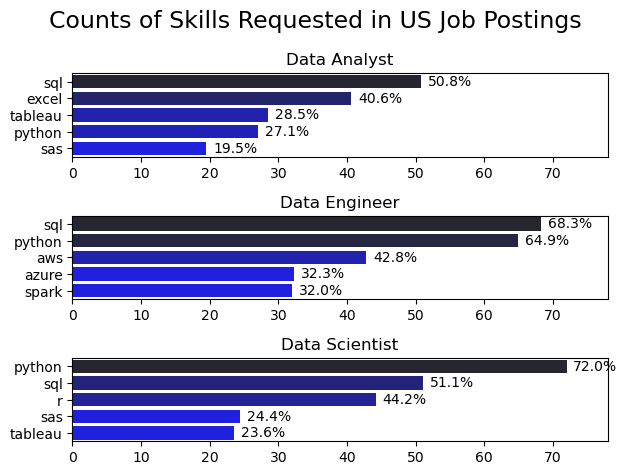

In [ ]:
fig, ax = plt.subplots(len(Jobs), 1)
for i,job_title in enumerate(Jobs):
    df_plot = dfMerged[dfMerged['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    for j, v in enumerate(df_plot['percentage']):
        ax[i].text(v + 1, j, f'{v:.1f}%', va='center')
    
    # ax[i].set_xlim(0, 45000) 

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=17)
fig.tight_layout()


In [97]:
df_plot['percentage']

11    23.6
10    24.4
4     44.2
2     51.1
0     72.0
Name: percentage, dtype: float64